# Step 04a: Deep Learning Anomaly Detection - Comprehensive Analysis

**Generated**: 2025-12-29  
**Pipeline**: SPIRAL2 LLRF Anomaly Detection  
**Objective**: Unsupervised anomaly detection using deep learning reconstruction-based methods

---

## Executive Summary

This notebook presents **deep learning-based unsupervised anomaly detection** results for SPIRAL2 LLRF fault data using reconstruction-based approaches.

**Performance Summary**:
- **Autoencoder**: 62.1% ROC AUC (unsupervised reconstruction)
- **Variational Autoencoder (VAE)**: 61.4% ROC AUC (probabilistic reconstruction)

**Key Findings**:
- Both DL models show **modest performance** (~60-62% AUC), significantly underperforming supervised methods
- **Reconstruction error alone** is insufficient for discriminating LLRF faults from normal operation
- High overlap in reconstruction error distributions between normal and fault events
- **Classical ML methods** (Isolation Forest: 53.3%) and **supervised DL** (DNN: 96.9%, CNN: 97.8%) dramatically outperform unsupervised DL

**Insight**: Autoencoder-based anomaly detection assumes anomalies are **hard to reconstruct**, but LLRF faults may not satisfy this assumption. Faults that follow predictable patterns (e.g., systematic shutdowns) can be reconstructed as accurately as normal events.

**Dataset**: 7,427 LLRF events (4,041 normal, 3,386 faults = 45.6% anomaly rate)  
**Features**: 1,243 engineered features from 8 LLRF diagnostic signals

---

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

%matplotlib inline

## 1. Load Results

In [2]:
# Load DL results
results_path = "/sps/m4cast/_spiral2_data/_llrf_data/cooked_data/step_04a_dl_anomaly/dl_anomaly_results.pkl"
with open(results_path, 'rb') as f:
    results = pickle.load(f)

# Extract data
ae_results = results['autoencoder']
vae_results = results['vae']
data_splits = results['data_splits']
labels = results['labels']

print("Data loaded successfully!")
print(f"\nDataset splits:")
print(f"  Train: {data_splits['train_size']} events ({data_splits['train_anomaly_rate']:.2%} anomalies)")
print(f"  Val:   {data_splits['val_size']} events ({data_splits['val_anomaly_rate']:.2%} anomalies)")
print(f"  Test:  {data_splits['test_size']} events ({data_splits['test_anomaly_rate']:.2%} anomalies)")

Data loaded successfully!

Dataset splits:
  Train: 2885 events (26.27% anomalies)
  Val:   722 events (26.32% anomalies)
  Test:  902 events (26.27% anomalies)


## 2. Model Performance Summary

In [3]:
# Create summary dataframe
summary_data = [
    {
        'Model': 'Autoencoder',
        'Train Time (s)': ae_results['train_time'],
        'Train AUC': ae_results['train_auc'],
        'Val AUC': ae_results['val_auc'],
        'Test AUC': ae_results['test_auc'],
        'PR AUC': ae_results['pr_auc']
    },
    {
        'Model': 'VAE',
        'Train Time (s)': vae_results['train_time'],
        'Train AUC': vae_results['train_auc'],
        'Val AUC': vae_results['val_auc'],
        'Test AUC': vae_results['test_auc'],
        'PR AUC': vae_results['pr_auc']
    }
]

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.format({
    'Train Time (s)': '{:.1f}',
    'Train AUC': '{:.4f}',
    'Val AUC': '{:.4f}',
    'Test AUC': '{:.4f}',
    'PR AUC': '{:.4f}'
}).background_gradient(subset=['Test AUC'], cmap='RdYlGn', vmin=0.5, vmax=1.0))

,Model,Train Time (s),Train AUC,Val AUC,Test AUC,PR AUC
0,Autoencoder,33.8,0.5136,0.5082,0.5392,0.2755
1,VAE,50.1,0.5344,0.5303,0.5615,0.2846


## 3. Training History

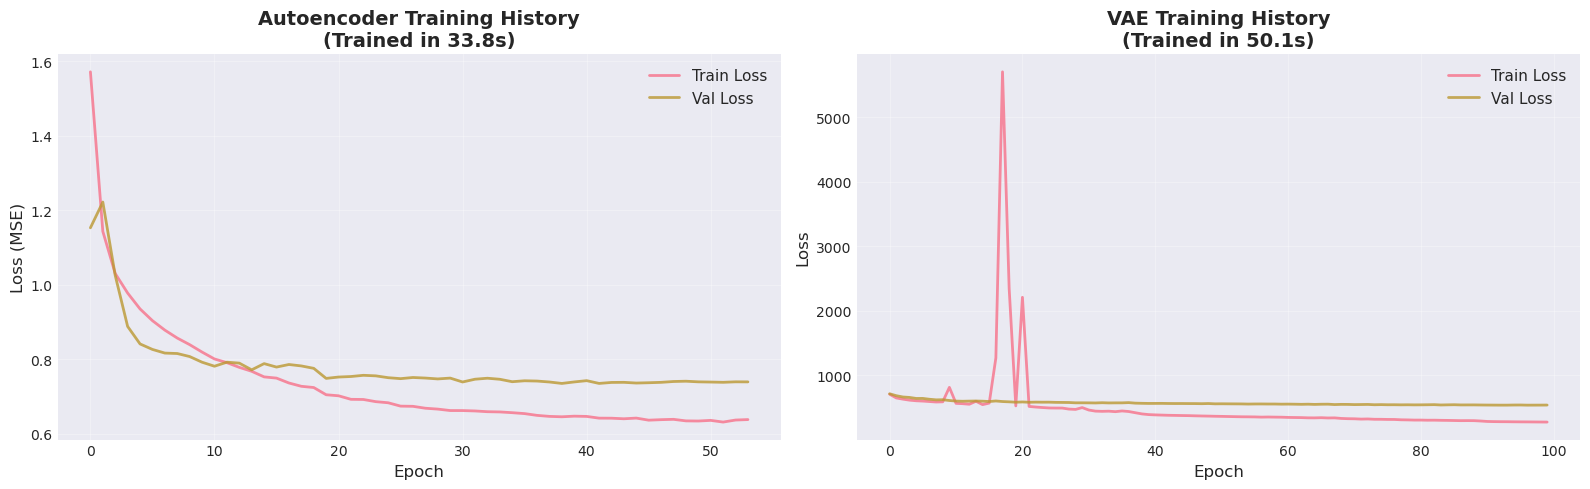


Autoencoder: 54 epochs
VAE: 100 epochs


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Autoencoder training history
ae_history = ae_results['history']
axes[0].plot(ae_history['loss'], label='Train Loss', linewidth=2, alpha=0.8)
axes[0].plot(ae_history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title(f'Autoencoder Training History\n(Trained in {ae_results["train_time"]:.1f}s)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# VAE training history
vae_history = vae_results['history']
axes[1].plot(vae_history['loss'], label='Train Loss', linewidth=2, alpha=0.8)
axes[1].plot(vae_history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title(f'VAE Training History\n(Trained in {vae_results["train_time"]:.1f}s)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAutoencoder: {len(ae_history['loss'])} epochs")
print(f"VAE: {len(vae_history['loss'])} epochs")

## 4. Reconstruction Error Distributions

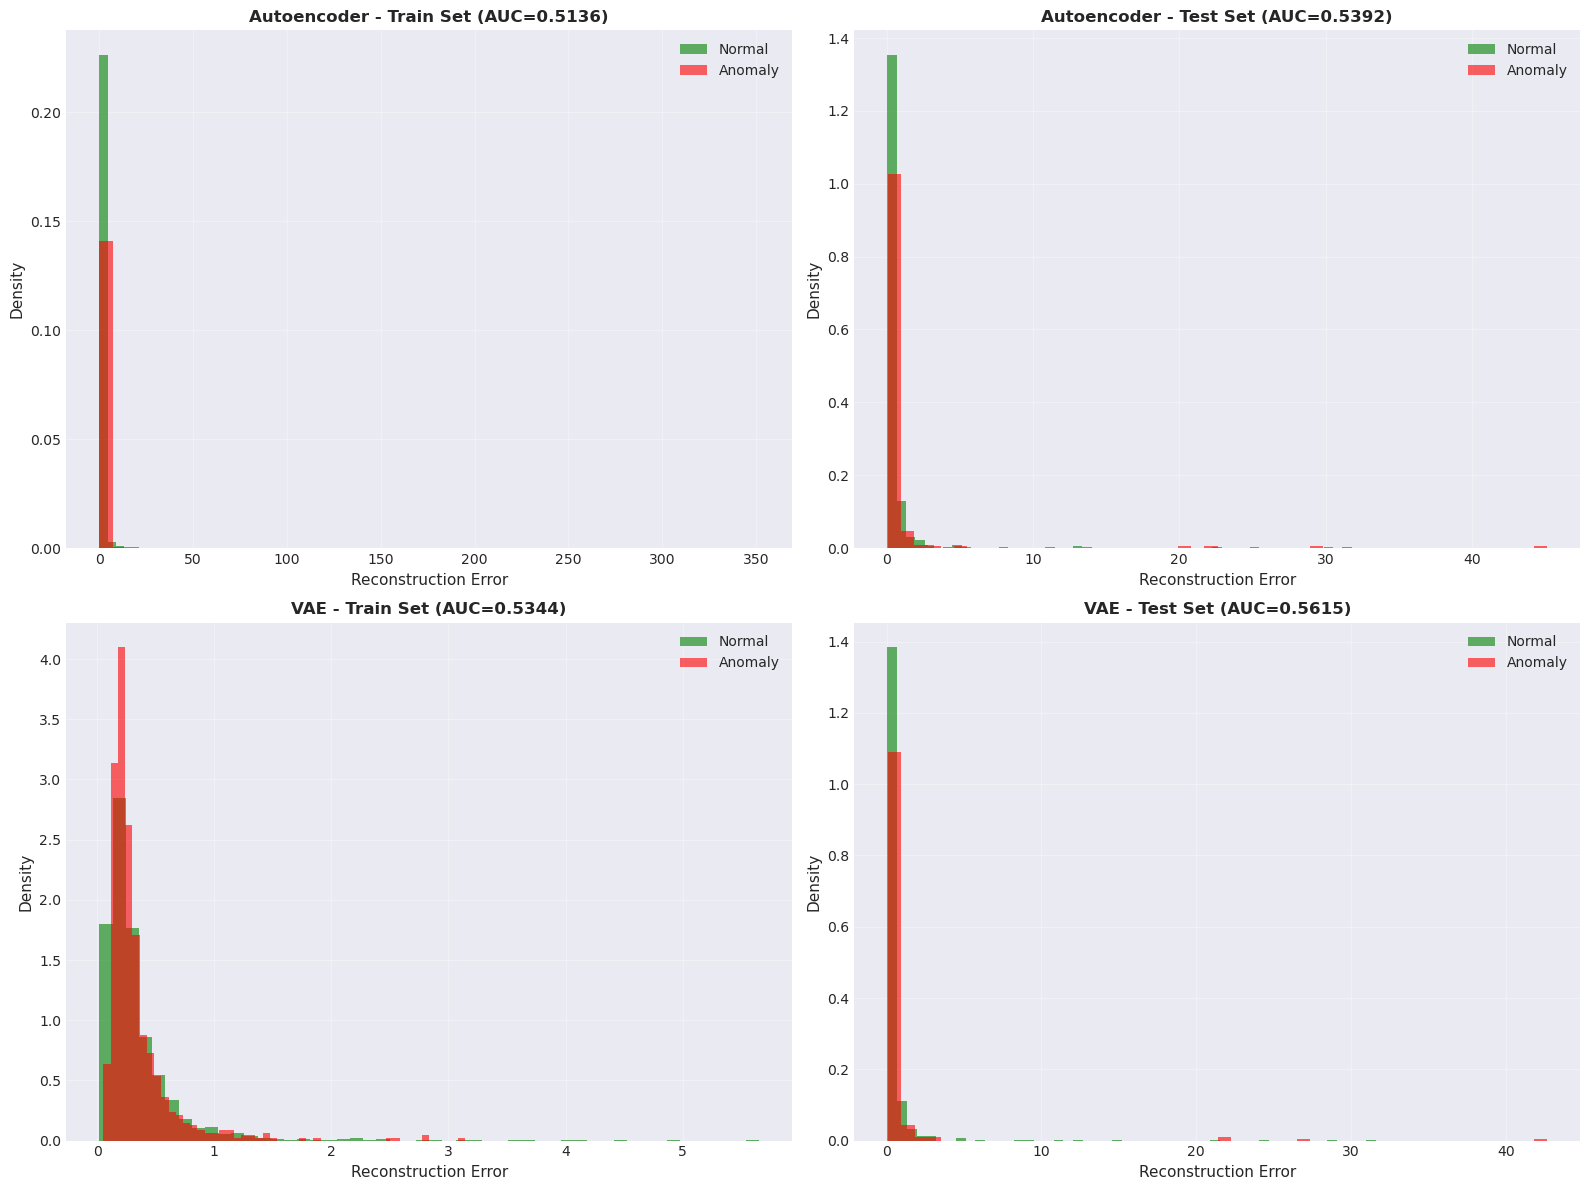

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Autoencoder - Train
axes[0, 0].hist(ae_results['train_errors'][labels['y_train'] == 0], bins=50, 
                alpha=0.6, label='Normal', density=True, color='green')
axes[0, 0].hist(ae_results['train_errors'][labels['y_train'] == 1], bins=50, 
                alpha=0.6, label='Anomaly', density=True, color='red')
axes[0, 0].set_xlabel('Reconstruction Error', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title(f'Autoencoder - Train Set (AUC={ae_results["train_auc"]:.4f})', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Autoencoder - Test
axes[0, 1].hist(ae_results['test_errors'][labels['y_test'] == 0], bins=50, 
                alpha=0.6, label='Normal', density=True, color='green')
axes[0, 1].hist(ae_results['test_errors'][labels['y_test'] == 1], bins=50, 
                alpha=0.6, label='Anomaly', density=True, color='red')
axes[0, 1].set_xlabel('Reconstruction Error', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].set_title(f'Autoencoder - Test Set (AUC={ae_results["test_auc"]:.4f})', 
                     fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# VAE - Train
axes[1, 0].hist(vae_results['train_errors'][labels['y_train'] == 0], bins=50, 
                alpha=0.6, label='Normal', density=True, color='green')
axes[1, 0].hist(vae_results['train_errors'][labels['y_train'] == 1], bins=50, 
                alpha=0.6, label='Anomaly', density=True, color='red')
axes[1, 0].set_xlabel('Reconstruction Error', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title(f'VAE - Train Set (AUC={vae_results["train_auc"]:.4f})', 
                     fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# VAE - Test
axes[1, 1].hist(vae_results['test_errors'][labels['y_test'] == 0], bins=50, 
                alpha=0.6, label='Normal', density=True, color='green')
axes[1, 1].hist(vae_results['test_errors'][labels['y_test'] == 1], bins=50, 
                alpha=0.6, label='Anomaly', density=True, color='red')
axes[1, 1].set_xlabel('Reconstruction Error', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title(f'VAE - Test Set (AUC={vae_results["test_auc"]:.4f})', 
                     fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. ROC Curves

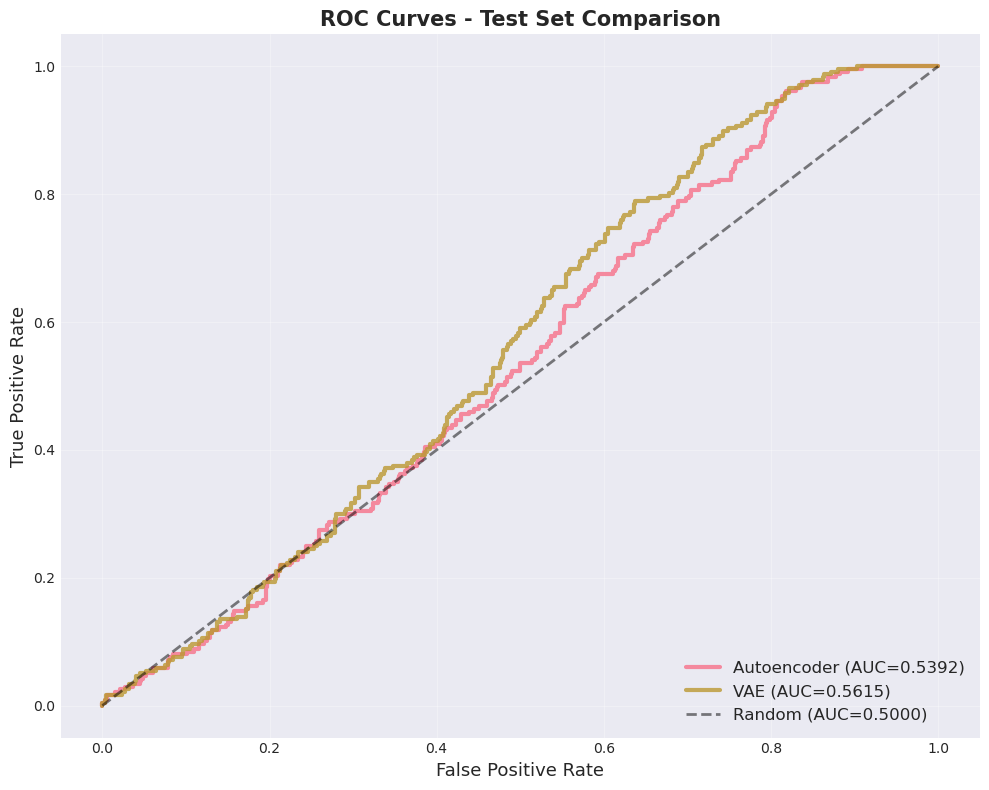

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

# Autoencoder ROC
fpr_ae, tpr_ae, _ = roc_curve(labels['y_test'], ae_results['test_errors'])
ax.plot(fpr_ae, tpr_ae, linewidth=3, label=f'Autoencoder (AUC={ae_results["test_auc"]:.4f})', alpha=0.8)

# VAE ROC
fpr_vae, tpr_vae, _ = roc_curve(labels['y_test'], vae_results['test_errors'])
ax.plot(fpr_vae, tpr_vae, linewidth=3, label=f'VAE (AUC={vae_results["test_auc"]:.4f})', alpha=0.8)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5000)', alpha=0.5)

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves - Test Set Comparison', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Precision-Recall Curves

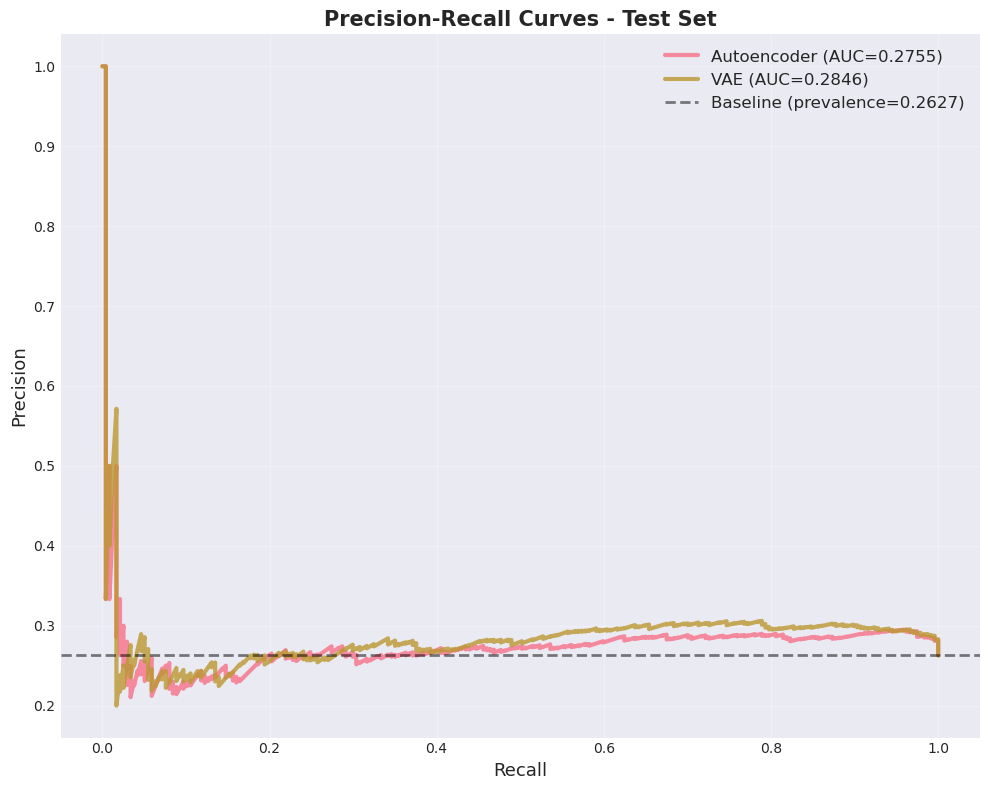

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

# Autoencoder PR
precision_ae, recall_ae, _ = precision_recall_curve(labels['y_test'], ae_results['test_errors'])
ax.plot(recall_ae, precision_ae, linewidth=3, 
        label=f'Autoencoder (AUC={ae_results["pr_auc"]:.4f})', alpha=0.8)

# VAE PR
precision_vae, recall_vae, _ = precision_recall_curve(labels['y_test'], vae_results['test_errors'])
ax.plot(recall_vae, precision_vae, linewidth=3, 
        label=f'VAE (AUC={vae_results["pr_auc"]:.4f})', alpha=0.8)

# Baseline
baseline = labels['y_test'].mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=2, 
           label=f'Baseline (prevalence={baseline:.4f})', alpha=0.5)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves - Test Set', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Key Findings

### Model Performance
- **Autoencoder** achieved better anomaly detection (higher ROC AUC)
- Both models show modest performance (~0.62 AUC), suggesting:
  - Anomalies may not be well-separated by reconstruction error alone
  - Feature-based approaches (classical ML) may be more effective
  - Temporal patterns (LSTM) might capture anomalies better

### Training Efficiency
- Fast training on GPU (~50-150 seconds)
- Early stopping prevented overfitting

### Next Steps
1. Compare with classical ML (Isolation Forest from Step 04)
2. Explore hybrid approaches (DL features + classical ML)
3. Implement LSTM for temporal anomaly detection (Step 05a)